In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

 After we have successfully imported the required libraries and configuration 
 We will import the data set that we will be working on

In [2]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


 I will now use a scatter plot to understand the relationship between height and weight 

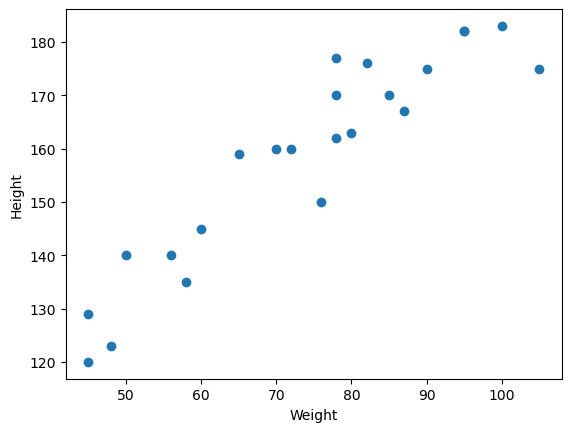

In [3]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [4]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [5]:
X = df[['Weight']]
#Independent features should be in a data frame
#Mathematically speaking we need to build it like a matrix
Y = df['Height']
np.array(X).shape

(23, 1)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
#Train test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [8]:
#Lets standardize the training and test data using Z-scoreabs
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#This is the standardized form with mean = 0 and variance = 1 
X_test
mean_test = X_test.mean()
variance_test = X_test.var()
print(f'Mean: {mean_test}')
print(f'Variance: {variance_test}')

Mean: 0.3147783487965052
Variance: 1.391720706839821


Now we will apply simple linear regression

In [9]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [10]:
regression.fit(X_train, Y_train)

LinearRegression()

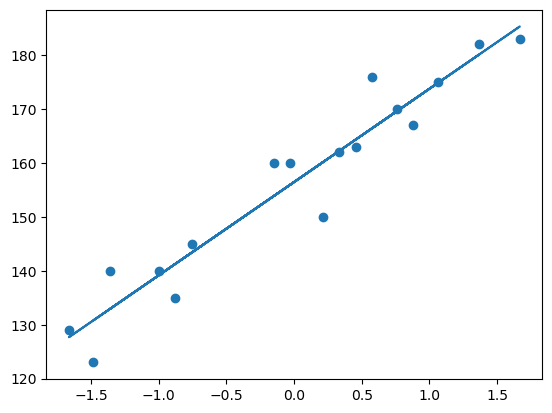

Intercept: 156.47058823529412 & Slope: [17.2982057]


In [11]:
plt.scatter(X_train, Y_train)
plt.plot(X_train, regression.predict(X_train))
plt.show()
intercept = regression.intercept_
slope = regression.coef_
print(f'Intercept: {intercept} & Slope: {slope}')

Now we will generate our predicted values

# Linear regression value of coefficient
Intercept: 156.47058823529412 & Slope: [17.2982057]
y_predicted = 156.47058823529412 + 17.2982057*X_test

In [12]:
y_predicted = regression.predict(X_test)
y_predicted

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

Now lets check the performance metrics

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [14]:
mse = mean_squared_error(Y_test, y_predicted)
mae = mean_absolute_error(Y_test, y_predicted)
rmse = np.sqrt(mse)
print(f'Mean squared error(MSE): {mse}')
print(f'Mean absolute error(MAE): {mae}')
print(f'Root mean squared error(RMSE): {rmse}')

Mean squared error(MSE): 114.84069295228699
Mean absolute error(MAE): 9.665125886795005
Root mean squared error(RMSE): 10.716374991212605


Lets check the R square value:
R^2 = 1 - (RSS/TSS)

In [15]:
from sklearn.metrics import r2_score

In [16]:
score = r2_score(Y_test, y_predicted)
print(f'R square score: {score * 100}%')

R square score: 73.60826717981276%


# Adjusted R^2
### adjusted R2 = 1 - [(1-R2)*(N - 1)/(N - K - 1)]
N : number of observations, K : number of independent variables

In [17]:
adjusted_r2 = 1 - ((1-score)*(len(Y_test) - 1)/(len(Y_test) - X_test.shape[1] - 1))
print(f'Adjusted R2 score: {adjusted_r2  * 100}%')

Adjusted R2 score: 67.01033397476594%


In [24]:
new_data = pd.DataFrame({
    'Weight': [56, 100, 74]
})
regression.predict(scaler.transform(new_data))

array([139.21064662, 185.31934779, 158.0732971 ])